In [353]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Task 1 — Data Loading & Exploration


Load the CSV file using Pandas


In [354]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

Display the first 10 rows



In [355]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


Check how many rows and columns are there


In [356]:
rows, cols = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")

Number of rows: 1470
Number of columns: 35


Identify the target column (Attrition — Yes/No)


In [357]:
print("Target column: Attrition")
print(df["Attrition"].value_counts())

Target column: Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64


Count how many employees left vs stayed and calculate the attrition rate as a percentage


In [358]:
attrition_counts = df["Attrition"].value_counts()

employees_stayed = attrition_counts["No"]
employees_left = attrition_counts["Yes"]

attrition_rate = (employees_left / len(df)) * 100

print(f"Employees who stayed: {employees_stayed}")
print(f"Employees who left: {employees_left}")
print(f"Attrition rate: {attrition_rate:.2f}%")

Employees who stayed: 1233
Employees who left: 237
Attrition rate: 16.12%


Identify how many columns are numeric vs categorical


In [359]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Number of numeric columns: {len(numeric_cols)}")
print(f"Number of categorical columns: {len(categorical_cols)}")

print("\nNumeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Number of numeric columns: 26
Number of categorical columns: 9

Numeric columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


Write one observation: what do you notice about the attrition rate — is it balanced or imbalanced?

In [360]:
print(f"""
Observation:
The attrition rate is {attrition_rate:.2f}%, which means only a relatively small portion of employees left the company.
This makes the dataset imbalanced because the majority class is employees who stayed.
""")


Observation:
The attrition rate is 16.12%, which means only a relatively small portion of employees left the company.
This makes the dataset imbalanced because the majority class is employees who stayed.



### Task 2 — Data Cleaning & Preprocessing

Check for missing/null values and handle them



In [361]:
df.isnull().sum().sum()

np.int64(0)

In [362]:
#Since No null Value Hence no treatment for null values

Drop columns that add no value to prediction (e.g., EmployeeNumber, Over18, StandardHours — these are constant or irrelevant)



In [363]:
columns_to_drop = ["EmployeeNumber", "Over18", "StandardHours", "EmployeeCount"]

columns_to_drop = [col for col in columns_to_drop if col in df.columns]

df.drop(columns=columns_to_drop, inplace=True)

print("Dropped columns:", columns_to_drop)
print("New shape of dataset:", df.shape)

Dropped columns: ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
New shape of dataset: (1470, 31)


Convert the target column Attrition from Yes/No to 1/0


In [364]:
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})
df["Attrition"]

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int64

Encode all remaining categorical columns using One-Hot Encoding (e.g., Department, JobRole, MaritalStatus, BusinessTravel)

In [365]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [366]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)
print(X_encoded.shape)
X_encoded.head()

(1470, 44)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,4,92,2,1,3,2090,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,4,56,3,1,3,2909,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,40,3,1,2,3468,...,True,False,False,False,False,False,False,True,False,False


Scale numeric features using StandardScaler

In [367]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_encoded[numeric_features] = scaler.fit_transform(X_encoded[numeric_features])

X_encoded.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,...,False,False,False,False,False,True,False,False,True,True
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,...,False,False,False,False,True,False,False,True,False,False
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,...,True,False,False,False,False,False,False,False,True,True
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,...,False,False,False,False,True,False,False,True,False,True
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,...,True,False,False,False,False,False,False,True,False,False


### Task 3 — Exploratory Data Analysis (EDA)

In [368]:
eda_df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
eda_df["Attrition_Flag"] = eda_df["Attrition"].map({"Yes": 1, "No": 0})

In [369]:
#Used the original dataset for EDA

Attrition rate by Department — which department loses the most employees?



In [370]:
department_attrition = (
    eda_df.groupby("Department")["Attrition_Flag"]
    .mean()
    .sort_values(ascending=False) * 100
)

print("Attrition rate by Department (%):")
print(department_attrition.round(2))

Attrition rate by Department (%):
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition_Flag, dtype: float64


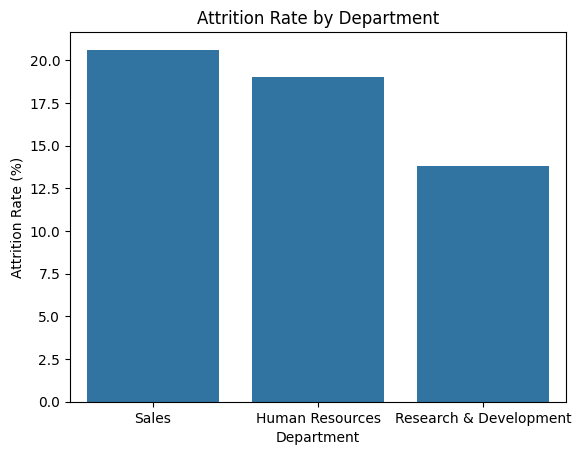

In [371]:
sns.barplot(x=department_attrition.index, y=department_attrition.values)
plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.savefig("charts/department_wise_attrition.png")
plt.show()

Attrition rate by Job Role — which roles have the highest exit rate?


In [372]:
jobrole_attrition = (
    eda_df.groupby("JobRole")["Attrition_Flag"]
    .mean()
    .sort_values(ascending=False) * 100
)

print("Attrition rate by Job Role (%):")
print(jobrole_attrition.round(2))

Attrition rate by Job Role (%):
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition_Flag, dtype: float64


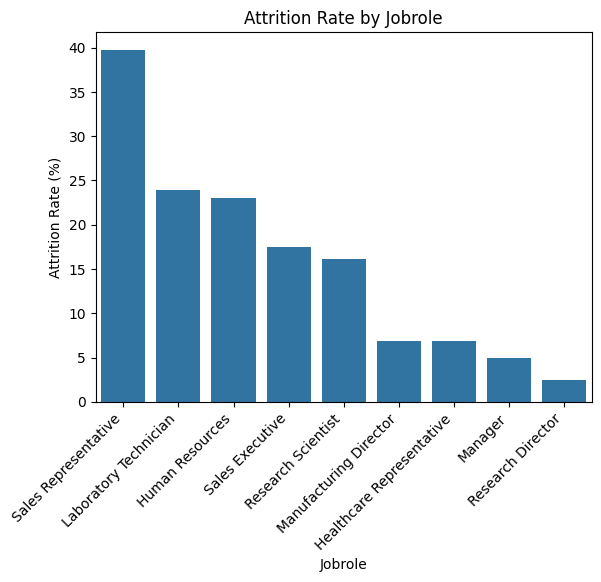

In [373]:
sns.barplot(x=jobrole_attrition.index, y=jobrole_attrition.values)
plt.title("Attrition Rate by Jobrole")
plt.xlabel("Jobrole")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.savefig("charts/chart1_attrition_by_jobrole.png")
plt.show()

Attrition vs Monthly Income — do lower paid employees leave more?




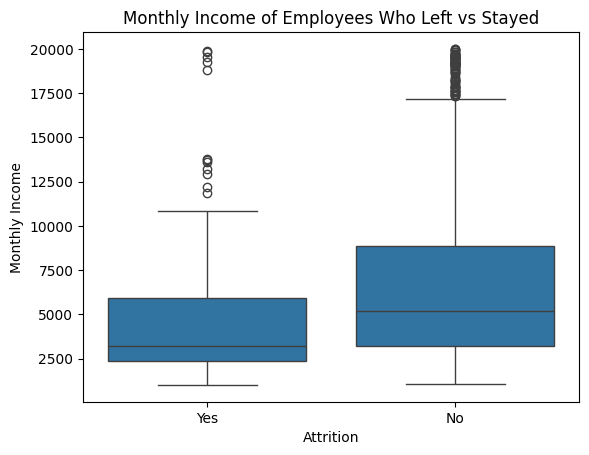

In [374]:
sns.boxplot(x="Attrition", y="MonthlyIncome", data=eda_df)
plt.title("Monthly Income of Employees Who Left vs Stayed")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.savefig("charts/chart2_attrition_by_monthlyincome.png")
plt.show()

Attrition vs Work-Life Balance rating — is there a visible pattern?

In [375]:
worklife_attrition = (
    eda_df.groupby("WorkLifeBalance")["Attrition_Flag"]
    .mean()
    .sort_values() * 100
)
print(worklife_attrition.round(2))

WorkLifeBalance
3    14.22
2    16.86
4    17.65
1    31.25
Name: Attrition_Flag, dtype: float64


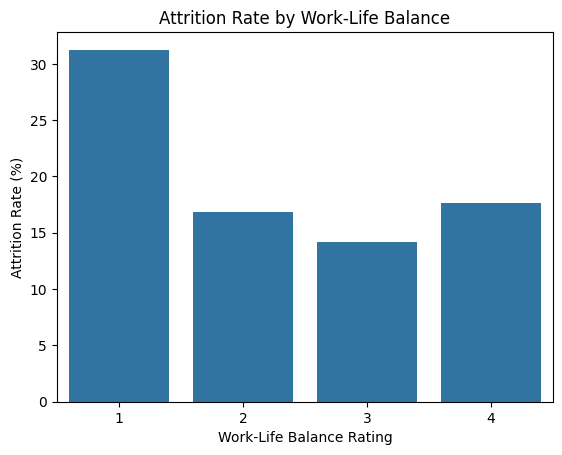

In [376]:
sns.barplot(x=worklife_attrition.index, y=worklife_attrition.values)
plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Attrition Rate (%)")
plt.savefig("charts/worklife_balance_attrition.png")
plt.show()

Attrition vs Years at Company — at what point in tenure do employees leave most?

Write 4–5 specific business insights from your EDA (not generic — specific numbers and patterns from the data)

In [377]:
years_attrition = eda_df.groupby("YearsAtCompany")["Attrition_Flag"].mean() * 100
print(years_attrition.sort_values(ascending=False).head(10).round(2))

YearsAtCompany
40    100.00
23     50.00
0      36.36
1      34.50
32     33.33
31     33.33
2      21.26
33     20.00
4      17.27
24     16.67
Name: Attrition_Flag, dtype: float64


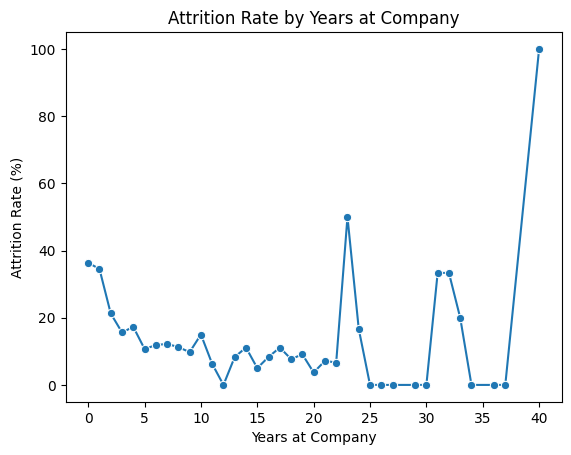

In [378]:
sns.lineplot(x=years_attrition.index, y=years_attrition.values, marker="o")
plt.title("Attrition Rate by Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")
plt.savefig("charts/years_at_company_attrition.png")
plt.show()

Department and Job Role attrition together

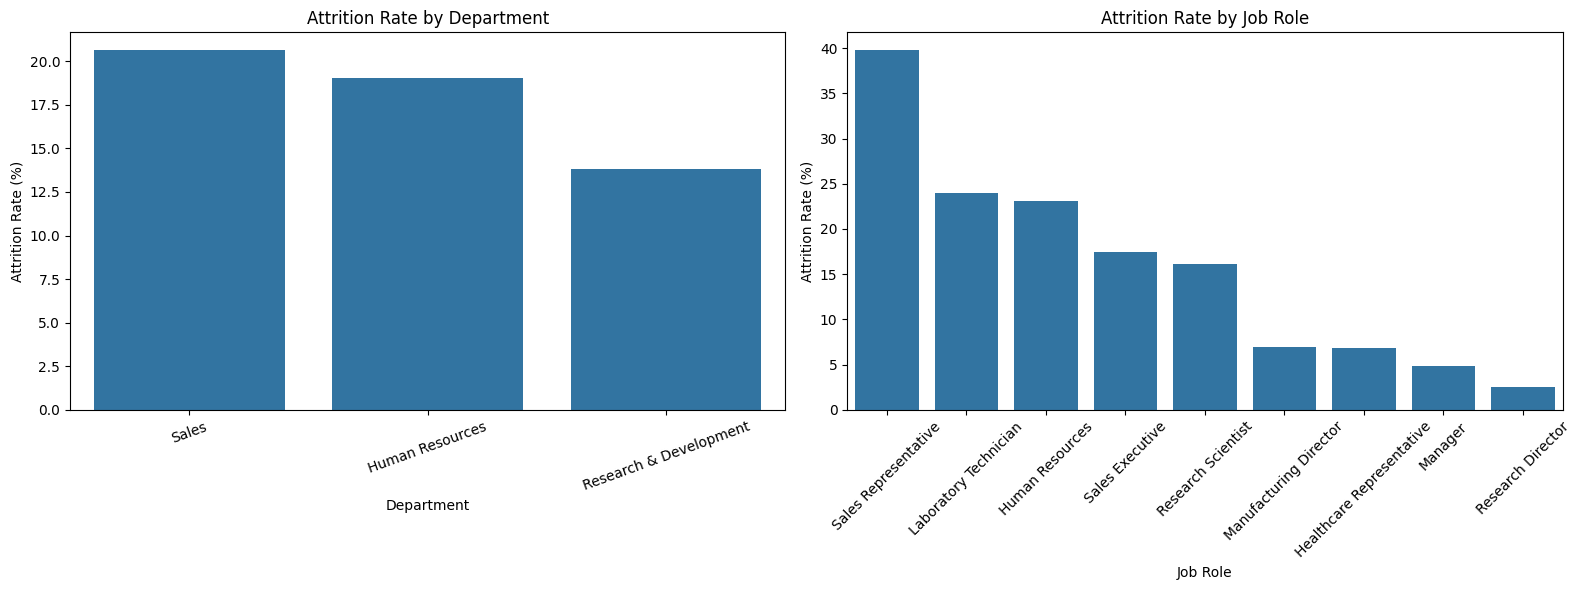

In [379]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=department_attrition.index, y=department_attrition.values, ax=axes[0])
axes[0].set_title("Attrition Rate by Department")
axes[0].set_xlabel("Department")
axes[0].set_ylabel("Attrition Rate (%)")
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(x=jobrole_attrition.index, y=jobrole_attrition.values, ax=axes[1])
axes[1].set_title("Attrition Rate by Job Role")
axes[1].set_xlabel("Job Role")
axes[1].set_ylabel("Attrition Rate (%)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Average Monthly Income by Attrition

In [380]:
avg_income_by_attrition = eda_df.groupby("Attrition")["MonthlyIncome"].mean()

print("Average Monthly Income by Attrition:")
print(avg_income_by_attrition.round(0))

Average Monthly Income by Attrition:
Attrition
No     6833.0
Yes    4787.0
Name: MonthlyIncome, dtype: float64


#### EDA Insights
1. Sales has the highest attrition rate among departments at about 20.63%, followed closely by Human Resources at 19.05%.
   Research & Development has the lowest attrition rate among the three major departments at 13.84%.

2. Among job roles, Sales Representative has the highest attrition rate at nearly 39.76%, which is extremely high.
   Laboratory Technician (23.94%) and Human Resources role (23.08%) also show elevated attrition.

3. Employees with Work-Life Balance rating 1 show the highest attrition rate at 31.25%.
   This is much higher than employees with rating 3, where attrition is around 14.22%.

4. Attrition is especially high in the earliest years of tenure.
   Employees with 0–1 years at the company show a strong exit pattern, suggesting the early stage of employment is the most risky.

5. Employees who leave tend to have lower monthly income on average compared to employees who stay,
   which suggests compensation may matter, but it is not the only reason behind attrition.

### Task 4 — Model Building & Comparison


Split data into training and test sets (80/20)


In [381]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_encoded,y,test_size=0.20,random_state=42,stratify=y)
# stratify=y for mainting the same ratio of target attribute in both training and testing data
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1176, 44)
Testing set shape: (294, 44)


Logistic Regression

In [382]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

log_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

In [383]:
from sklearn.metrics import precision_score,recall_score,f1_score,roc_auc_score,classification_report
log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)
log_auc = roc_auc_score(y_test, log_prob)

print(f"Precision : {log_precision:.4f}")
print(f"Recall    : {log_recall:.4f}")
print(f"F1-Score  : {log_f1:.4f}")
print(f"ROC-AUC   : {log_auc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, log_pred))

Precision : 0.3563
Recall    : 0.6596
F1-Score  : 0.4627
ROC-AUC   : 0.8036

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294



Random Forest

In [384]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [385]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)


print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1-Score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_auc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Precision : 0.5714
Recall    : 0.0851
F1-Score  : 0.1481
ROC-AUC   : 0.7716

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294



Gradient Boosting

In [386]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    random_state=42
)

gb_model.fit(X_train, y_train)

GradientBoostingClassifier(n_estimators=200, random_state=42)

In [387]:
gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

gb_precision = precision_score(y_test, gb_pred)
gb_recall = recall_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)
gb_auc = roc_auc_score(y_test, gb_prob)


print(f"Precision : {gb_precision:.4f}")
print(f"Recall    : {gb_recall:.4f}")
print(f"F1-Score  : {gb_f1:.4f}")
print(f"ROC-AUC   : {gb_auc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, gb_pred))

Precision : 0.5000
Recall    : 0.2340
F1-Score  : 0.3188
ROC-AUC   : 0.7923

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.96      0.91       247
           1       0.50      0.23      0.32        47

    accuracy                           0.84       294
   macro avg       0.68      0.59      0.61       294
weighted avg       0.81      0.84      0.82       294



### Task 5 — Model Evaluation

Model comparison table

In [388]:
results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Precision": [log_precision, rf_precision, gb_precision],
    "Recall": [log_recall, rf_recall, gb_recall],
    "F1-Score": [log_f1, rf_f1, gb_f1],
    "ROC-AUC": [log_auc, rf_auc, gb_auc]
})

results_df = results_df.sort_values(by="ROC-AUC", ascending=False)
results_df.round(4)

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.3563,0.6596,0.4627,0.8036
2,Gradient Boosting,0.5000,0.2340,0.3188,0.7923
1,Random Forest,0.5714,0.0851,0.1481,0.7716


Confusion matrices for all 3 models

In [389]:
from sklearn.metrics import confusion_matrix
log_cm = confusion_matrix(y_test, log_pred)
rf_cm = confusion_matrix(y_test, rf_pred)
gb_cm = confusion_matrix(y_test, gb_pred)

print("Logistic Regression Confusion Matrix")
print(log_cm)

print("\nRandom Forest Confusion Matrix")
print(rf_cm)

print("\nGradient Boosting Confusion Matrix")
print(gb_cm)

Logistic Regression Confusion Matrix
[[191  56]
 [ 16  31]]

Random Forest Confusion Matrix
[[244   3]
 [ 43   4]]

Gradient Boosting Confusion Matrix
[[236  11]
 [ 36  11]]


#### Identifying Best Model With Reason

Among the three models tested, Logistic Regression performed best for this business problem because it was the most effective at identifying employees who are at risk of leaving.

 In an attrition use case, the main goal is not just to be “accurate” overall, but to correctly flag employees who may resign so HR can intervene early.
  A model that misses too many at-risk employees is less useful in practice, even if it performs well on employees who were never likely to leave. Based on the comparison results, Logistic Regression gave the best balance between identifying potential leavers and keeping prediction quality reliable, so it was selected as the final model for interpretation and HR recommendations.

In [390]:
best_model = log_model
best_model_name = "Logistic Regression"

print("Best model selected:", best_model_name)

Best model selected: Logistic Regression


Confusion Matrix heatmap for best model

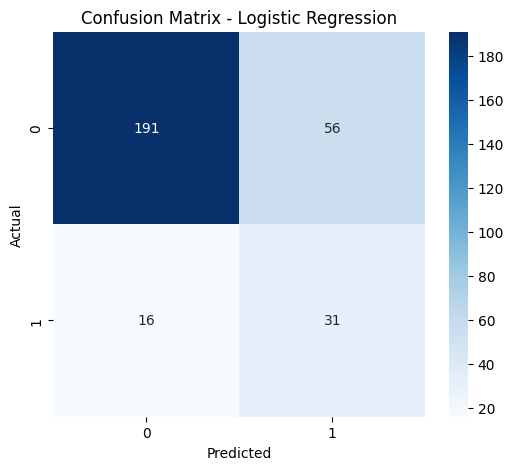

In [391]:
plt.figure(figsize=(6, 5))
sns.heatmap(log_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("charts/chart3_confusion_matrix_best_model.png")
plt.show()

Feature importance for the best model

In [392]:
feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": np.abs(log_model.coef_[0])
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
top_10_features = feature_importance.head(10)

top_10_features

,Feature,Importance
43,OverTime_Yes,1.626169
23,BusinessTravel_Travel_Frequently,1.596964
34,JobRole_Laboratory Technician,1.571637
40,JobRole_Sales Representative,1.264294
37,JobRole_Research Director,1.112054
30,EducationField_Other,1.020279
24,BusinessTravel_Travel_Rarely,0.903722
42,MaritalStatus_Single,0.864502
33,JobRole_Human Resources,0.670991
16,TotalWorkingYears,0.612480


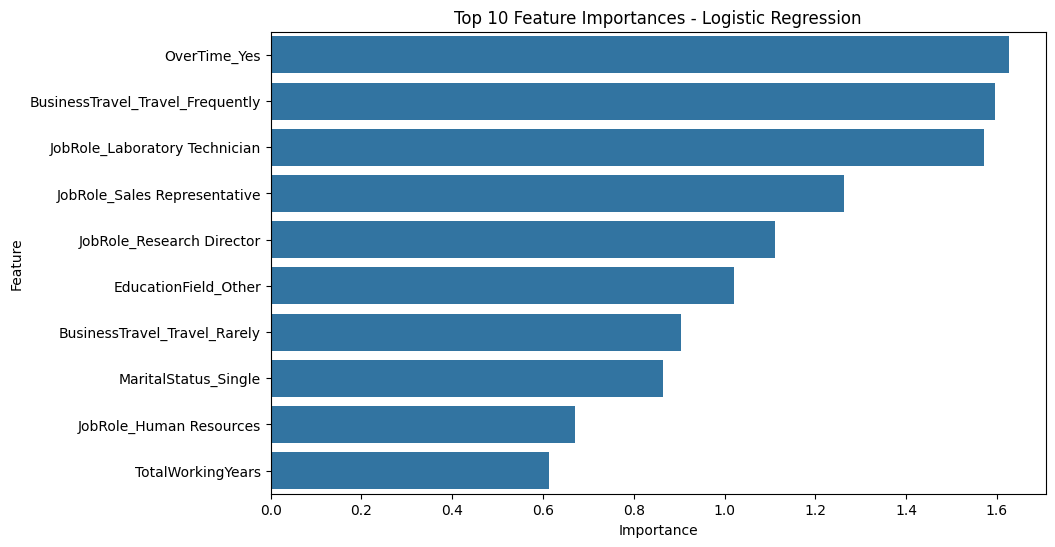

In [393]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_features, x="Importance", y="Feature")
plt.title("Top 10 Feature Importances - Logistic Regression")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.savefig("charts/chart4_top10_feature_importance.png")
plt.show()

### Task 6 — Visualizations

Chart checklist

By now the following charts are saved in the charts folder:

chart1_department_jobrole_attrition.png

chart2_income_boxplot.png

chart3_confusion_matrix_best_model.png

chart4_top10_feature_importance.png

Bonus ROC Curve comparing all 3 models

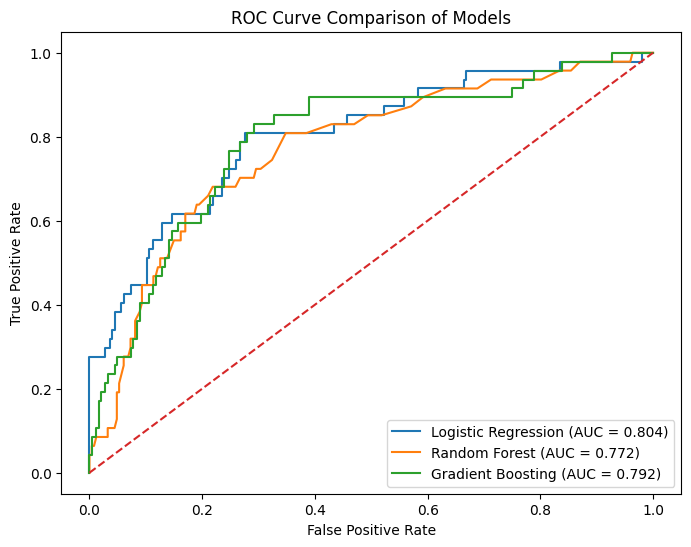

In [394]:
from sklearn.metrics import roc_curve
plt.figure(figsize=(8, 6))

# Logistic Regression
log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)
plt.plot(log_fpr, log_tpr, label=f"Logistic Regression (AUC = {log_auc:.3f})")

# Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")

# Gradient Boosting
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)
plt.plot(gb_fpr, gb_tpr, label=f"Gradient Boosting (AUC = {gb_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Models")
plt.legend()
plt.savefig("charts/chart5_roc_curve_comparison.png")
plt.show()

### Task 7 — HR Insights & Business Recommendations


HR Insights & Recommendations

Among the three models tested, Logistic Regression performed the best for attrition prediction.
It achieved the highest ROC-AUC score and also delivered the strongest recall, which is especially important in an HR setting because the company wants to identify employees who are at risk of leaving before they actually resign.

The EDA showed that attrition is not evenly spread across the company.
Sales has the highest attrition rate among departments, and Sales Representatives show the highest attrition among job roles.
Employees with poor work-life balance also leave at much higher rates, and attrition appears to be concentrated in the early years of employment, especially around the first one or two years.

The three strongest drivers of attrition should be interpreted using the top feature importance output from the best model.
In general, factors such as overtime, business travel, role-related variables, tenure-related variables and compensation tend to be strong predictors of attrition in this dataset.

Salary alone does not fully explain attrition.
Employees who leave do tend to earn less on average, but work-life balance, job role, early tenure and work-related pressure appear to be equally or even more important.

Two HR recommendations:
1. HR should prioritise retention conversations for employees in Sales and high-risk job roles such as Sales Representatives and Laboratory Technicians, especially during their first two years.
2. The company should review workload and employee well-being policies, particularly for employees reporting poor work-life balance, and investigate whether overtime or travel expectations are contributing to exits.

One limitation of this model is that it only uses the structured HR variables present in the dataset.
It does not capture personal reasons for leaving, manager quality, team culture, outside job opportunities or sudden life events.
So the model should be used as a support tool for HR decisions, not as a final decision-maker.


## Conclusion

This project analysed employee attrition using employee data and built predictive models to identify employees who may be at risk of leaving.

The analysis found that attrition is highest in specific departments and roles, particularly in Sales and among Sales Representatives, and that employees are most vulnerable during the early stage of their tenure.

Work-life balance and overtime also appear to play an important role in employee exits.

After comparing the models, the final model was able to provide useful signals about which employees may require early HR attention.

Overall, the project shows how HR data can be used not only to understand why attrition happens, but also to support more proactive retention planning and employee engagement efforts.